In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.0 MB/s eta 0:00:00


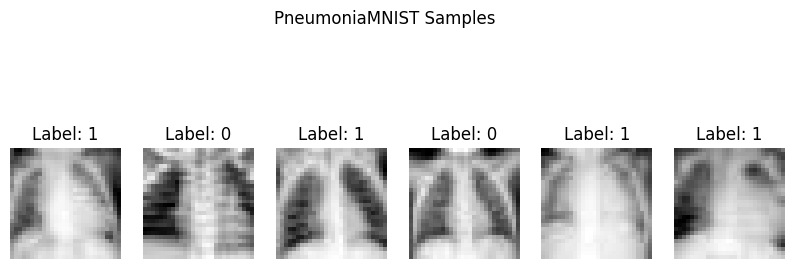

In [ ]:
# @title Load Dataset
import torch
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST, BreastMNIST,PathMNIST
import numpy as np

dataset_P = PneumoniaMNIST(split="test", download=True, size=28)
# dataset_P = PathMNIST(split="test", download=True, size=28)
def show_samples(dataset, title, num_samples=6):
    plt.figure(figsize=(10, 4))
    for i in range(num_samples):
        img, label = dataset[i]
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Label: {label[0]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()
show_samples(dataset_P, "PneumoniaMNIST Samples")

In [ ]:
# @title Data Split
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_dataset = PneumoniaMNIST(split="train", download=True, transform=transform,size=28)
# train_dataset = PathMNIST(split="train", download=True, transform=transform)
print(len(train_dataset))
test_dataset = PneumoniaMNIST(split="test", download=True, transform=transform,size=28)
# test_dataset = PathMNIST(split="test", download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


4708


In [ ]:
# @title Simple CNN Model
import torch
import torch.nn as nn
import torch.nn.functional as F
####### 28 size
class SmallCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super(SmallCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 28 -> 14
        x = self.pool(F.relu(self.conv2(x)))  # 14 -> 7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


class BetterCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=2,dropout=0.5):
        super(BetterCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(64 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # 28x28
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # -> 14x14
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # -> 7x7
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # -> 3x3

        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x



In [ ]:
# @title ResNet  Model
######### Resnet 8 veriosn
import torch
import torch.nn as nn
import torch.nn.functional as F


class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride,
            padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1,
            padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Adjust shortcut if dimensions change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


# ----------------------------
# ResNet-8
# ----------------------------

class ResNet8(nn.Module):
    def __init__(self, num_classes=2,in_channels=1):
        super(ResNet8, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels, 16, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = BasicBlock(16, 16, stride=1)
        self.layer2 = BasicBlock(16, 32, stride=2)
        self.layer3 = BasicBlock(32, 64, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

|||||||||
1
2
|||||||||
Epoch [1/15]
Train Loss: 0.1646
Train Acc: 93.03%
Test Acc: 89.74%
Epoch Time: 1.41 seconds
--------------------
Epoch [2/15]
Train Loss: 0.1200
Train Acc: 95.35%
Test Acc: 84.62%
Epoch Time: 1.40 seconds
--------------------
Epoch [3/15]
Train Loss: 0.0860
Train Acc: 96.86%
Test Acc: 85.26%
Epoch Time: 1.44 seconds
--------------------
Epoch [4/15]
Train Loss: 0.0678
Train Acc: 97.49%
Test Acc: 84.46%
Epoch Time: 1.43 seconds
--------------------
Epoch [5/15]
Train Loss: 0.0562
Train Acc: 97.83%
Test Acc: 89.42%
Epoch Time: 1.43 seconds
--------------------
Epoch [6/15]
Train Loss: 0.0428
Train Acc: 98.51%
Test Acc: 83.65%
Epoch Time: 1.86 seconds
--------------------
Epoch [7/15]
Train Loss: 0.0347
Train Acc: 98.66%
Test Acc: 82.37%
Epoch Time: 1.56 seconds
--------------------
Epoch [8/15]
Train Loss: 0.0388
Train Acc: 98.47%
Test Acc: 85.90%
Epoch Time: 1.44 seconds
--------------------
Epoch [9/15]
Train Loss: 0.0271
Train Acc: 98.83%
Test Acc: 86.54%
Epoch

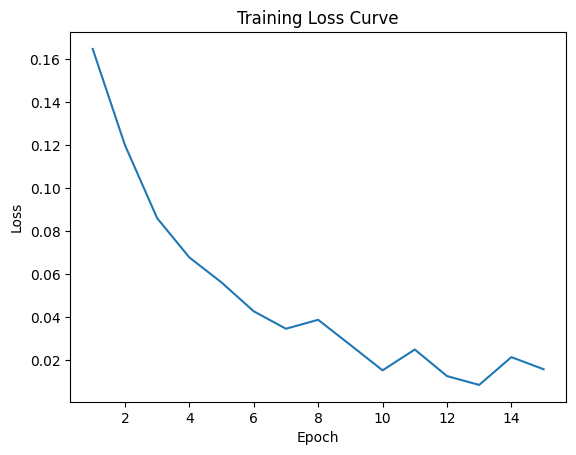

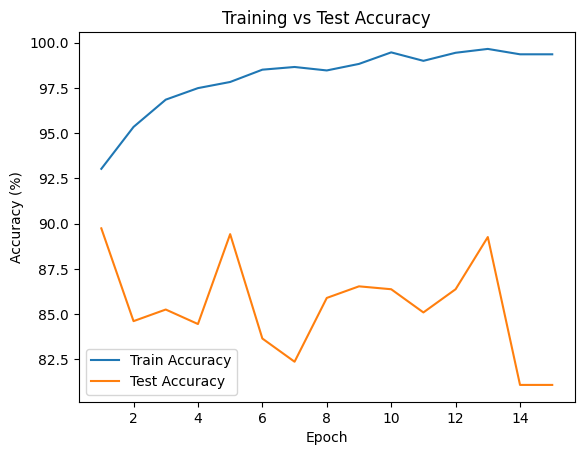

In [ ]:
# @title Training Loop
import torch.optim as optim
import time
import random

# seed = 41

# torch.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)
# np.random.seed(seed)
# random.seed(seed)

# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_class=len(train_loader.dataset.info["label"])
in_channels = train_dataset[0][0].shape[0]
print("|||||||||")
print(in_channels)
print(num_class)
print("|||||||||")
model_selection= "!resnet"
# model = SmallCNN(num_classes=num_class,in_channels=in_channels).to(device)
model = BetterCNN(num_classes=num_class,in_channels=in_channels).to(device)
if model_selection == "resnet":
  model = ResNet8(num_classes=num_class,in_channels=in_channels).to(device)

num_epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)
train_losses = []
train_accuracies = []
test_accuracies = []

def train_epoch():
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return running_loss / len(train_loader), accuracy


def test_epoch():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy



for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = train_epoch()
    test_acc = test_epoch()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    epoch_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}%")
    print(f"Test Acc: {test_acc:.2f}%")
    print(f"Epoch Time: {epoch_time:.2f} seconds")
    print("--------------------")
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, num_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()
plt.figure()
plt.plot(range(1, num_epochs + 1), train_accuracies)
plt.plot(range(1, num_epochs + 1), test_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Test Accuracy")
plt.legend(["Train Accuracy", "Test Accuracy"])
plt.show()

#**Results**
#1- Simple CNN 28x28

epoch 11:  
Train Acc: 97.75%  
Test Acc: 90.22%

#2- Simple CNN 64x64

epoch 8:  
Train Acc: 95.56%  
Test Acc: 89.26%

#3- ResNet-18 28x28

epoch 5:  
Train Acc: 98.11%  
Test Acc: 90.38%

#4- ResNet-18 64x64

epoch 8:  
Train Acc: 99.15%  
Test Acc: 90.06%

#4- ResNet-8 28x28

epoch 7:  14 sec CPU
Train Acc: 98.64%
Test Acc: 91.03%
Train Acc: 98.02%
Test Acc: 90.38%

